## Лаба 3

#### Задание 1. Проверка следствия из центральной предельной теоремы
Проводится эксперимент по вытягиванию шариков.В урне 5 красных шаров и 3 белых. Случайное событие А =  вытягивание 2-х красных и одного белого шаров.

1.Определить количество испытаний Na, при которых вероятность отклонения относительной частоты от теоретической вероятности на ε=±a будет равна Ka, если a= 0.2, Ka =0.993.

In [50]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

In [58]:
def comb(n, k):
    return math.comb(n, k)

total_ways = comb(8, 3) # Общее число способов вытянуть 3 шара из 8
event_ways = comb(5, 2) * comb(3, 1) # 2 красных И 1 белый
p = event_ways / total_ways
q = 1 - p

e = 0.2
Ka = 0.993

# Находим аргумент функции Лапласа (x), при котором 2*Phi(x) = Ka
# Так как в scipy norm.cdf - это функция распределения (от -inf до x)
x_phi = norm.ppf(Ka + ((1 - Ka) / 2))                                                              

#Вычисляем n из формулы: x_phi = e * sqrt(Na / (p * q))
Na = math.ceil((x_phi**2 * p * q) / (e**2)) 
print(f"Вероятность p: {p:.4f}")
print(f"Значение x для Ka = {Ka}: {x_phi:.4f}")
print(f"Необходимое количество испытаний Na: {Na}")

Вероятность p: 0.5357
Значение x для Ka = 0.993: 2.6968
Необходимое количество испытаний Na: 46


In [64]:
def f():
    urn = ['R'] * 5 + ['W'] * 3 
    s1 = random.s1(urn, 3) 
    return s1.count('R') == 2 and s1.count('W') == 1 

N = 0
for _ in range(Na): 
    if f():
        N += 1

Wa = N / Na  
diff = abs(Wa - p) 

print(f"Ввероятность p: {p:.4f}")
print(f"Количество испытаний Na: {Na}")
print(f"Относительная частота Wa: {Wa:.4f}")
print(f"|{Wa:.4f} - {p:.4f}| = {diff:.4f}")
print(f"Результат: {diff < e}, отклонение {diff:.4f} < {e})")

AttributeError: module 'random' has no attribute 's1'

2.Проверьте адекватность полученных значений  Na и Nb. Для этого:

2.1 Создайте программу по имитации эксперимента с вытягиванием шариков (события А).

2.2 Определите истинную вероятность события А. 

2.3 Определить относительную частоту Wa события А в серии из Na испытаний.
Проверьте выполнение неравенства:

|Wa – p| < а (1)

In [67]:
a = 0.2
Ka = 0.993

p = (math.comb(5, 2) * math.comb(3, 1)) / math.comb(8, 3)
q = 1 - p

x_phi = norm.ppf(Ka + (1 - Ka) / 2)
Na = math.ceil((x_phi**2 * p * q) / (a**2))

def f():
    urn = ['R'] * 5 + ['W'] * 3 
    sample = random.sample(urn, 3) #вытягиваем 3 шарика
    return sample.count('R') == 2 and sample.count('W') == 1 

N = 0
for _ in range(Na): #серия из Na испытаний
    if f():
        N += 1

Wa = N / Na  # Относительная частота
diff = abs(Wa - p) # Отклонение

print(f"Ввероятность p: {p:.4f}")
print(N)
print(f"Количество испытаний Na: {Na}")
print(f"Относительная частота Wa: {Wa:.4f}")
print(" ")
print(f"Проверка неравенства |Wa - p| < a:")
print(f"|{Wa:.4f} - {p:.4f}| = {diff:.4f}")
print(f"Результат: {diff < e}, отклонение {diff:.4f} < {e})")

Ввероятность p: 0.5357
20
Количество испытаний Na: 46
Относительная частота Wa: 0.4348
 
Проверка неравенства |Wa - p| < a:
|0.4348 - 0.5357| = 0.1009
Результат: True, отклонение 0.1009 < 0.2)


2.4 Повторите 100 серий испытаний, аналогичных п. 2.3. Определите процентное 
соотношение выполнения условия (1), а также отобразите результат графически (ось абсцисс 
— номер серии, ось ординат — Wa, дополнительно постройте линию y = p и y = p±ε).

<>:42: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
<>:43: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
<>:42: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
<>:43: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
C:\Users\admin\AppData\Local\Temp\ipykernel_14228\2336455667.py:42: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
  plt.axhline(y=p + a, color='green', linestyle='--', label='$p + \epsilon$')
C:\Users\admin\AppData\Local\Temp\ipykernel_14228\2336455667.py:43: SyntaxWarning: "\e" is 

Вероятность p: 0.5357
Количество испытаний Na: 46
Процент выполнения условия |Wa - p| < 0.2: 994%


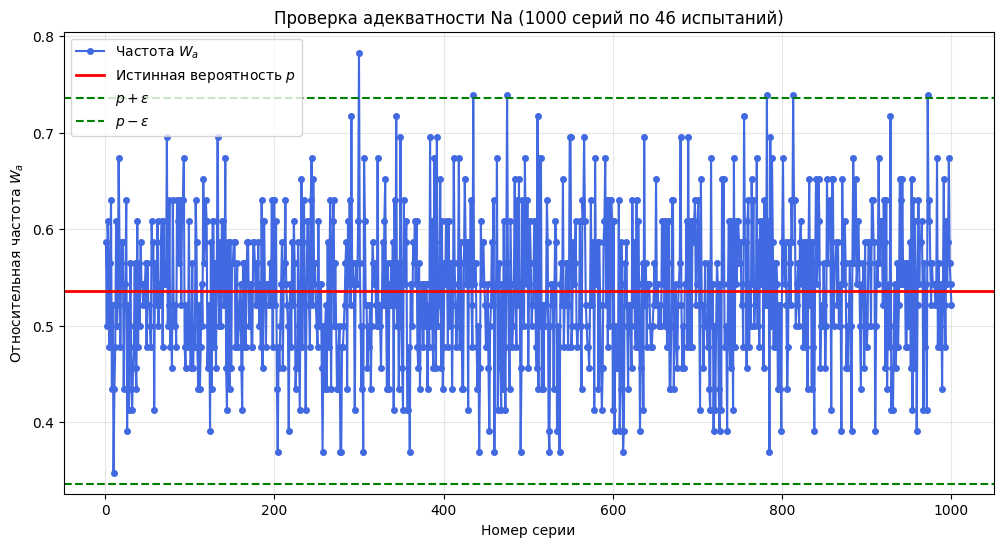

In [68]:
a = 0.2          
Ka = 0.993      

p = (math.comb(5, 2) * math.comb(3, 1)) / math.comb(8, 3)
q = 1 - p
x_phi = norm.ppf(Ka + (1 - Ka) / 2)

Nb = math.ceil((x_phi**2 * p * q) / (a**2))

print(f"Вероятность p: {p:.4f}")
print(f"Количество испытаний Na: {Nb}")

def run_series(n_trials):
    S = 0
    urn = ['R'] * 5 + ['W'] * 3
    
    for _ in range(n_trials):
        sample = random.sample(urn, 3)
        if sample.count('R') == 2 and sample.count('W') == 1:
           S += 1
    return S / n_trials

# 5. Проведение 100 серий испытаний
num_series = 1000
wa_list = []
success_in_series = 0

for i in range(num_series):
    wa = run_series(Nb)
    wa_list.append(wa)
    
    if abs(wa - p) < a: # Проверка условия |Wa - p| < a
        success_in_series += 1

print(f"Процент выполнения условия |Wa - p| < {a}: {success_in_series}%")

plt.figure(figsize=(12, 6))
plt.plot(range(1, num_series + 1), wa_list, marker='o', linestyle='-', color='royalblue', label='Частота $W_a$', markersize=4)

# Линии уровней
plt.axhline(y=p, color='red', linewidth=2, label='Истинная вероятность $p$')
plt.axhline(y=p + a, color='green', linestyle='--', label='$p + \epsilon$')
plt.axhline(y=p - a, color='green', linestyle='--', label='$p - \epsilon$')

plt.title(f'Проверка адекватности Na ({num_series} серий по {Nb} испытаний)')
plt.xlabel('Номер серии')
plt.ylabel('Относительная частота $W_a$')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

3.Как изменится вероятность , если провести Na испытаний, а  уменьшить в 10 раз?
Как изменится вероятность , если уменьшить Na  в два раза?

In [49]:
# уменьшааю a в 10 раз (a_new = 0.02), оставляю Na прежним
a_new = a / 10
s1 = 0
wa_list1 = []

# уменьшаю Na в 2 раза (Na_new = Na // 2), оставляю a прежним
Na_new = Na // 2
s2 = 0
wa_list2 = []

for _ in range(1000):
    wa = run_series(Na)
    wa_list1.append(wa)
    if abs(wa - p) < a_new:
        s1 += 1
        
    wa_low_n = run_series(Na_new)
    wa_list2.append(wa_low_n)
    if abs(wa_low_n - p) < a:
        s2 += 1

print(f"При уменьшении a в 10 раз (до {a_new}), надежность упала до: {s1/10:.2f}%")
print(f"При уменьшении Na в 2 раза (до {Na_new}), надежность упала до: {s2/10:.2f}%")


При уменьшении a в 10 раз (до 0.1), надежность упала до: 82.40%
При уменьшении Na в 2 раза (до 23), надежность упала до: 100.00%


#### Задание 2. Определение параметров закона распределения генеральной совокупности

Сделать реализацию выборки объемом N элементов из генеральной совокупности, 
распределенной по логнормальному закону распределения с параметрами, указанными в 
табл. 1.

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import lognorm  

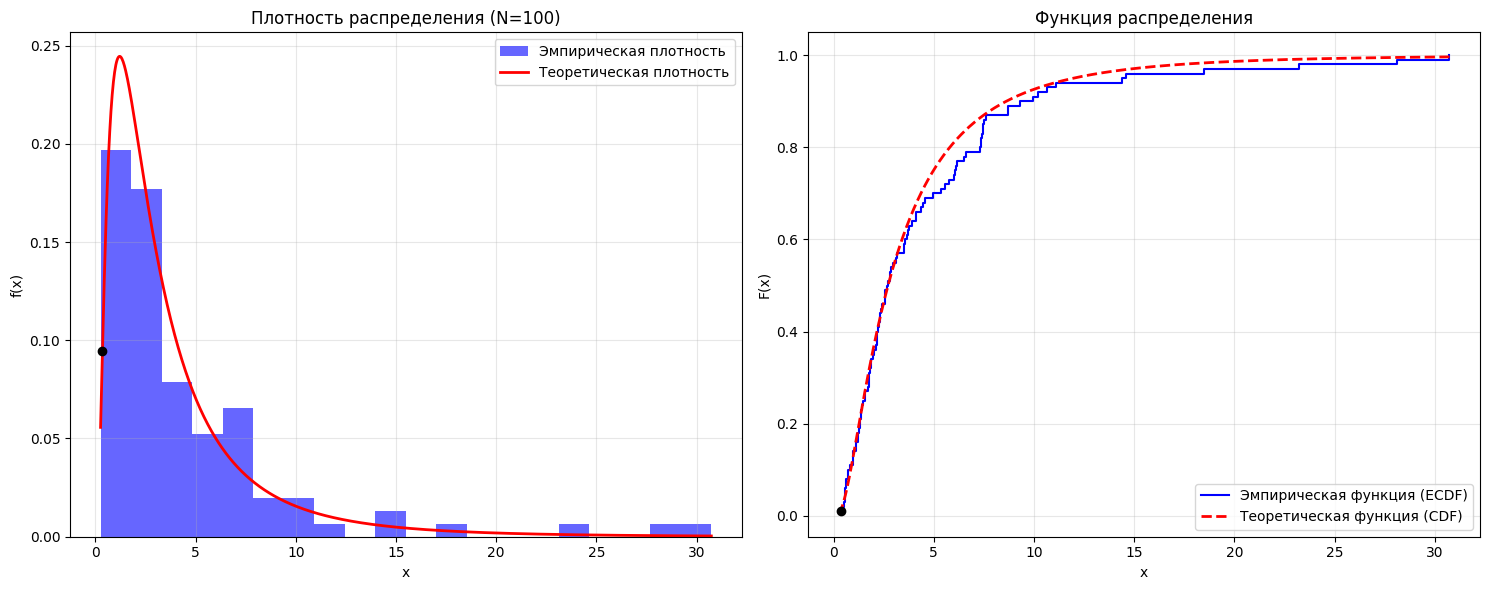

Параметры из таблицы: b=0.9, a=1
Параметры из fit: b=0.9595, a=1.0655
[False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False

In [80]:
b = 0.9  # в формуле b
a = 1    # в формуле a
N = 100        # объем выборки

# Параметры для scipy.stats.lognorm:
s = b
scale = np.exp(a)

sample = lognorm.rvs(s=s, scale=scale, size=N) # Генерируем выборку

# Подготовка данных для теоретических кривых
x = np.linspace(min(sample), max(sample), 1000)
x1 = 0.35
pdf_theo = lognorm.pdf(x, s=s, scale=scale)
cdf_theo = lognorm.cdf(x, s=s, scale=scale)

pdf_theo1 = lognorm.pdf(x1, s=s, scale=scale)
cdf_theo1 = lognorm.cdf(x1, s=s, scale=scale)

# 2. Построение графиков
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# ЛЕВЫЙ ГРАФИК: Гистограмма и плотность
ax1.hist(sample, bins=20, density=True, alpha=0.6, color='blue', label='Эмпирическая плотность')
ax1.plot(x, pdf_theo, 'r-', lw=2, label='Теоретическая плотность')
ax1.set_title(f'Плотность распределения (N={N})')
ax1.set_xlabel('x')
ax1.set_ylabel('f(x)')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.scatter(x1, pdf_theo1, color='black', zorder=5, label=f'f({x1}) = {pdf_theo1:.4f}')

# ПРАВЫЙ ГРАФИК: Эмпирическая функция распределения
x_sorted = np.sort(sample)
y_ecdf = np.arange(1, N + 1) / N


ax2.step(x_sorted, y_ecdf, where='post', label='Эмпирическая функция (ECDF)', color='blue')
ax2.plot(x, cdf_theo, 'r--', lw=2, label='Теоретическая функция (CDF)')
ax2.set_title('Функция распределения')
ax2.set_xlabel('x')
ax2.set_ylabel('F(x)')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.scatter(x1, cdf_theo1, color='black', zorder=5, label=f'f({x1}) = {cdf_theo1:.4f}')

plt.tight_layout()
plt.show()

# Дополнительно: проверка через fit (оценка параметров по выборке)
shape_fit, loc_fit, scale_fit = lognorm.fit(sample, floc=0) # фиксируем loc=0
print(f"Параметры из таблицы: b={b}, a={a}")
print(f"Параметры из fit: b={shape_fit:.4f}, a={np.log(scale_fit):.4f}")

print(pdf_theo == 0.35)


Для полученной выборки построить точечные оценки для математическое ожидание и дисперсии генеральной совокупности.

На основе созданной выборки оценить параметры закона распределения генеральной совокупности на основе метода scipy.stats.

In [43]:
mean_sample = np.mean(sample) #cреднее арифметическое всех чисел в выборке, оценка математического ожидания
var_sample = np.var(sample, ddof=1) # дисперсия
#ddof=1 (Delta Degrees of Freedom) крайне важен: он делит сумму квадратов отклонений на , а не на . Это делает оценку несмещенной (более точной для малых выборок, как наша 

print("Задание 3")
print(f"Выборочное среднее (E): {mean_sample:.4f}")
print(f"Выборочная дисперсия (D): {var_sample:.4f}\n")


# floc=0 фиксирует параметр сдвига (location), так как в нашей формуле его нет
shape_sci, loc_sci, scale_sci = lognorm.fit(sample, floc=0) #fit подбирает параметры методом максимального правдоподобия.
b_sci = shape_sci
a_sci = np.log(scale_sci) #scale, который равен e**a, чтоыб получить чистый параметр, надо взять нат логарифм (np.log) от полученного значения


print("Задание 4")
print(f"Оценка параметра b (shape): {b_sci:.4f}")
print(f"Оценка параметра a (log scale): {a_sci:.4f}\n")

Задание 3
Выборочное среднее (E): 3.6954
Выборочная дисперсия (D): 21.3896

Задание 4
Оценка параметра b (shape): 0.8126
Оценка параметра a (log scale): 0.9309



Реализовать метод моментов для определения параметров распределения. Выбрать моменты: 
а)  α1 и μ2;  б)  α2 и μ2;  в)  α1 и α2.   На основе созданной выборки определить параметры логнормального распределения.

In [44]:
# Эмпирические моменты:
alpha1 = np.mean(sample)          # начальный момент 1-го порядка
alpha2 = np.mean(sample**2)       # начальный момент 2-го порядка
mu2 = np.var(sample)              # центральный момент 2-го порядка (дисперсия)

# Через alpha1 и mu2
b_mom_a = np.sqrt(np.log(1 + mu2 / (alpha1**2)))
a_mom_a = np.log(alpha1) - (b_mom_a**2 / 2)

# Через alpha2 и mu2
# Так как alpha2 = mu2 + alpha1^2, выразим через alpha1:
alpha1_from_2 = np.sqrt(alpha2 - mu2)
b_mom_b = np.sqrt(np.log(alpha2 / (alpha1_from_2**2)))
a_mom_b = np.log(alpha1_from_2) - (b_mom_b**2 / 2)

# Через alpha1 и alpha2
b_mom_c = np.sqrt(np.log(alpha2 / (alpha1**2)))
a_mom_c = np.log(alpha1) - (b_mom_c**2 / 2)

print(f"Параметры через alpha1 и mu2: a={a_mom_a:.4f}, b={b_mom_a:.4f}")
print(f"Параметры через alpha2 и mu2: a={a_mom_b:.4f}, b={b_mom_b:.4f}")
print(f"Параметры через alpha1 и alpha2: a={a_mom_c:.4f}, b={b_mom_c:.4f}\n")

Параметры через alpha1 и mu2: a=0.8389, b=0.9677
Параметры через alpha2 и mu2: a=0.8389, b=0.9677
Параметры через alpha1 и alpha2: a=0.8389, b=0.9677



Для заданного закона распределения вывести соотношения для определения его 
параметров на основе метода максимального правдоподобия.  По найденным формулам 
вычислить значения параметров логнормального распределения на основе созданной 
выборки.

In [ ]:
# Для логнормального распределения оценки ММП считаются через логарифмы выборки
ln_sample = np.log(sample)

a_mle = np.mean(ln_sample) # среднее логарифмов
b_mle = np.sqrt(np.mean((ln_sample - a_mle)**2)) # станд. отклонение логарифмов

print("Задание 6")
print(f"Параметр a: {a_mle:.4f}")
print(f"Параметр b: {b_mle:.4f}")

--- Задание 6 ---
Параметр a: 0.9309
Параметр b: 0.8126


Результаты пунктов 5-7 внести в таблицу 2.

In [46]:
data = {
    "Метод": [
        "Заданные (табл. 1)", 
        "Метод scipy.stats", 
        "Метод моментов (a1 и mu2)", 
        "Метод моментов (a2 и mu2)", 
        "Метод моментов (a1 и a2)", 
        "Метод макс. правдоподобия"
    ],
    "a": [a, a_sci, a_mom_a, a_mom_b, a_mom_c, a_mle],
    "b": [b, b_sci, b_mom_a, b_mom_b, b_mom_c, b_mle]
}

df_results = pd.DataFrame(data)
df_results.to_string(index=False)
df_results

,Метод,a,b
0,Заданные (табл. 1),1.000000,0.900000
1,Метод scipy.stats,0.930859,0.812628
2,Метод моментов (a1 и mu2),0.838915,0.967651
3,Метод моментов (a2 и mu2),0.838915,0.967651
4,Метод моментов (a1 и a2),0.838915,0.967651
5,Метод макс. правдоподобия,0.930859,0.812628


По найденным параметрам построить функции и плотности распределения.

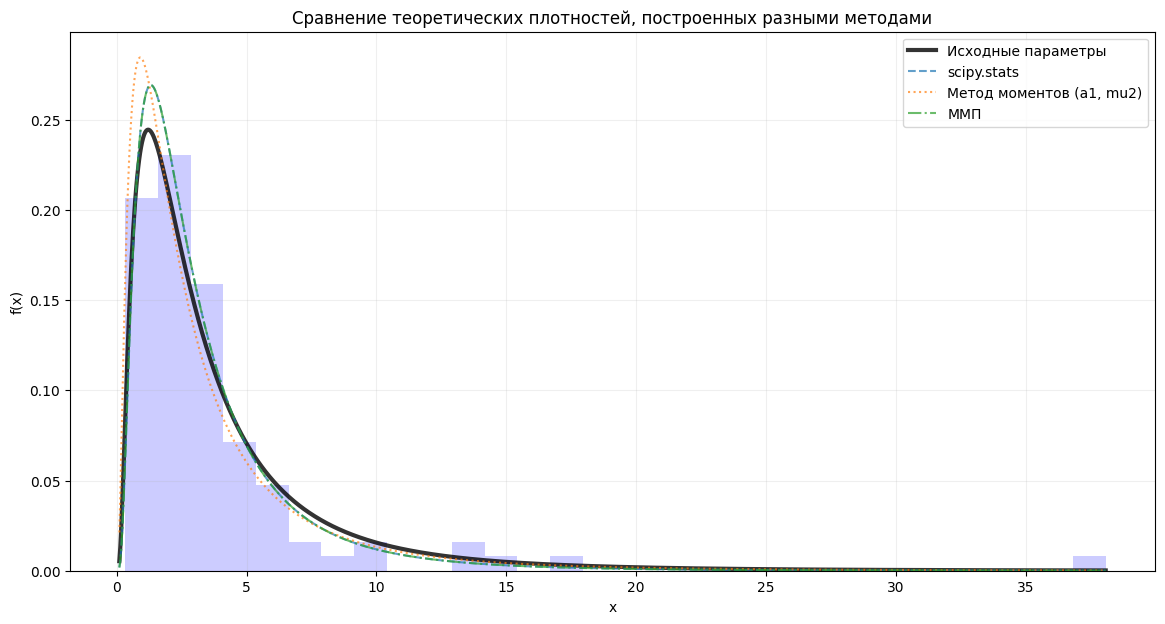

In [48]:
plt.figure(figsize=(14, 7))

x_plot = np.linspace(0.1, max(sample), 1000) # Создаем сетку для графиков плотности

# Оригинальная плотность
plt.plot(x_plot, lognorm.pdf(x_plot, s=b, scale=np.exp(a)), 
         'k-', lw=3, label='Исходные параметры', alpha=0.8)

# Плотность по методу scipy.stats
plt.plot(x_plot, lognorm.pdf(x_plot, s=b_sci, scale=np.exp(a_sci)), 
         '--', label='scipy.stats', alpha=0.7)

# Плотность по методу моментов (вариант а)
plt.plot(x_plot, lognorm.pdf(x_plot, s=b_mom_a, scale=np.exp(a_mom_a)), 
         ':', label='Метод моментов (a1, mu2)', alpha=0.7)

# Плотность по ММП
plt.plot(x_plot, lognorm.pdf(x_plot, s=b_mle, scale=np.exp(a_mle)), 
         '-.', label='ММП', alpha=0.7)

# Добавляем гистограмму выборки для фона
plt.hist(sample, bins=30, density=True, alpha=0.2, color='blue')

plt.title('Сравнение теоретических плотностей, построенных разными методами')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()
